# MOGA-Phonons Experiment Dataframe Explorer

This notebook loads a pickled dataframe produced by `build_experiment_dataframe_updated.py` and provides quick visual diagnostics for a MOGA-Phonons experiment.

Designed for files such as:

```text
dataframes/dataframe000009.pkl
dataframes/dataframe000009.summary.json
```


## 1. Imports and paths

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes this notebook is run from the repo root.
repo_root = Path.cwd()

experiment_id = "experiment000009"
df_path = repo_root / "dataframes" / "dataframe000011.pkl"
summary_path = repo_root / "dataframes" / "dataframe000011.summary.json"

print("Repo root:", repo_root)
print("Dataframe:", df_path)
print("Summary:", summary_path)


Repo root: /Users/jamunoz/Documents/GitHub/MOGA-Phonons
Dataframe: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/dataframe000011.pkl
Summary: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/dataframe000011.summary.json


## 2. Load dataframe and summary

In [2]:
df = pd.read_pickle(df_path)

if summary_path.exists():
    with open(summary_path, "r") as f:
        summary = json.load(f)
else:
    summary = {}

print("Rows:", len(df))
print("Columns:", len(df.columns))
display(pd.DataFrame(summary.items(), columns=["field", "value"]))
display(df.head())


Rows: 63000
Columns: 34


,field,value
0,n_simulations_in_experiment,42
1,n_yaml_tasks,63000
2,n_missing_simulation_dirs,0
3,n_missing_phonon_dirs,0
4,n_simulations_with_no_yaml,0
5,missing_simulation_dirs,[]
6,missing_phonon_dirs,[]
7,simulations_with_no_yaml,[]
8,n_rows,63000
9,n_load_errors,0


,simulation,generation,solution_index,rank,source,timestamp,mass,a_val,system_size,alpha0,...,stable,gamma_frequencies,distances,qpoints,frequencies,frequency_vector,simulation_path,generation_dir,solution_dir,band_yaml_path
0,simulation000462,1,1,0,population,2026-05-21T20:27:16.151259,50.0,2.0,5,9.488281,...,False,"[-1.682858, -1.682858, -1.682858]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.682858, -1.682858, -1.682858], [-1.681474...","[-1.682858, -1.682858, -1.682858, -1.6814747, ...",simulations/simulation000462,simulations/simulation000462/phonon_generation...,simulations/simulation000462/phonon_generation...,simulations/simulation000462/phonon_generation...
1,simulation000462,1,51,1,population,2026-05-21T20:27:16.151259,50.0,2.0,5,9.488281,...,False,"[-1.682858, -1.682858, -1.682858]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.682858, -1.682858, -1.682858], [-1.681474...","[-1.682858, -1.682858, -1.682858, -1.6814747, ...",simulations/simulation000462,simulations/simulation000462/phonon_generation...,simulations/simulation000462/phonon_generation...,simulations/simulation000462/phonon_generation...
2,simulation000462,1,25,2,population,2026-05-21T20:27:16.151259,50.0,2.0,5,6.482704,...,True,"[2.462054, 2.462054, 2.462054]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[2.462054, 2.462054, 2.462054], [2.4624426, 2...","[2.462054, 2.462054, 2.462054, 2.4624426, 2.46...",simulations/simulation000462,simulations/simulation000462/phonon_generation...,simulations/simulation000462/phonon_generation...,simulations/simulation000462/phonon_generation...
3,simulation000462,1,90,3,population,2026-05-21T20:27:16.151259,50.0,2.0,5,9.165818,...,True,"[2.9452577, 2.9452577, 2.9452577]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[2.9452577, 2.9452577, 2.9452577], [2.9460478...","[2.9452577, 2.9452577, 2.9452577, 2.9460478, 2...",simulations/simulation000462,simulations/simulation000462/phonon_generation...,simulations/simulation000462/phonon_generation...,simulations/simulation000462/phonon_generation...
4,simulation000462,1,35,4,population,2026-05-21T20:27:16.151259,50.0,2.0,5,6.517893,...,True,"[5.3469415, 5.3469415, 5.3469415]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[5.3469415, 5.3469415, 5.3469415], [5.346805,...","[5.3469415, 5.3469415, 5.3469415, 5.346805, 5....",simulations/simulation000462,simulations/simulation000462/phonon_generation...,simulations/simulation000462/phonon_generation...,simulations/simulation000462/phonon_generation...


## 3. Inspect dataframe schema

In [3]:
schema_rows = []
for c in df.columns:
    s = df[c]
    try:
        n_unique = s.nunique(dropna=True)
    except TypeError:
        n_unique = None
    schema_rows.append({
        "column": c,
        "dtype": str(s.dtype),
        "non_null": int(s.notna().sum()),
        "n_unique": n_unique,
    })

schema = pd.DataFrame(schema_rows)
display(schema)


,column,dtype,non_null,n_unique
0,simulation,object,63000,42.0
1,generation,int32,63000,300.0
2,solution_index,int32,63000,100.0
3,rank,int32,63000,5.0
4,source,object,63000,1.0
5,timestamp,object,63000,12600.0
6,mass,float32,63000,6.0
7,a_val,float32,63000,7.0
8,system_size,int32,63000,1.0
9,alpha0,float32,63000,3423.0


## 4. Basic experiment coverage

This checks how many rows are available per simulation and per generation.


count    300.0
mean     210.0
std        0.0
min      210.0
25%      210.0
50%      210.0
75%      210.0
max      210.0
dtype: float64

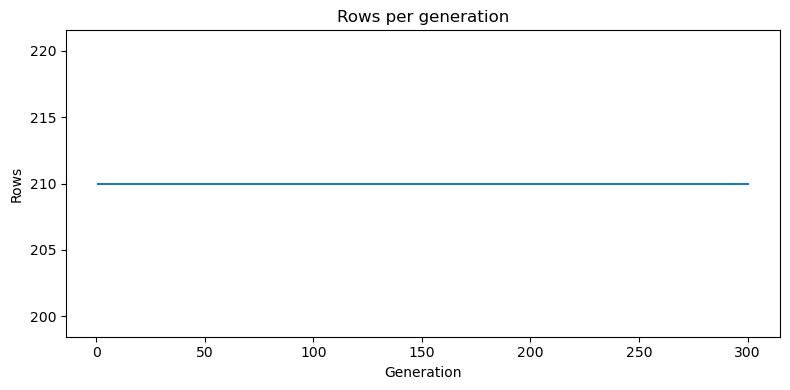

In [4]:
if "simulation_id" in df.columns:
    counts_by_sim = df.groupby("simulation_id").size().sort_index()
    display(counts_by_sim.describe())
    display(counts_by_sim.head())

    plt.figure(figsize=(10, 4))
    counts_by_sim.plot(kind="bar")
    plt.ylabel("Rows")
    plt.xlabel("Simulation")
    plt.title("Rows per simulation")
    plt.tight_layout()
    plt.show()

if "generation" in df.columns:
    counts_by_gen = df.groupby("generation").size().sort_index()
    display(counts_by_gen.describe())

    plt.figure(figsize=(8, 4))
    counts_by_gen.plot()
    plt.ylabel("Rows")
    plt.xlabel("Generation")
    plt.title("Rows per generation")
    plt.tight_layout()
    plt.show()


## 5. Stability overview

The builder adds `min_frequency`, `num_imaginary`, and `is_stable` when possible. These are useful first-pass metrics.


,min_frequency,max_frequency,num_imaginary
count,63000.000000,63000.000000,63000.000000
mean,-0.081198,6.694535,68.695206
std,0.946975,1.267484,120.921293
min,-6.884594,2.084889,0.000000
25%,-0.446542,5.826293,0.000000
50%,-0.039857,6.693332,12.000000
75%,0.385571,7.612289,94.000000
max,4.117368,10.785168,1495.000000


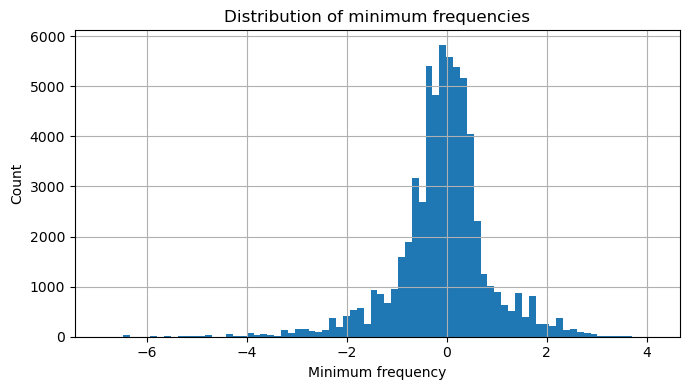

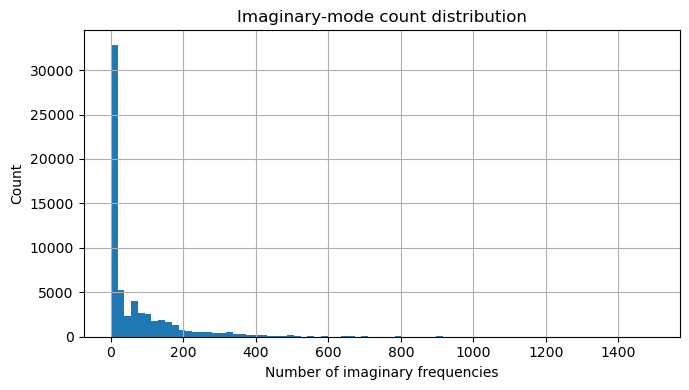

In [5]:
stability_cols = [c for c in ["min_frequency", "max_frequency", "num_imaginary", "is_stable"] if c in df.columns]
display(df[stability_cols].describe(include="all") if stability_cols else "No stability columns found.")

if "is_stable" in df.columns:
    stable_counts = df["is_stable"].value_counts(dropna=False)
    display(stable_counts)
    plt.figure(figsize=(5, 4))
    stable_counts.plot(kind="bar")
    plt.ylabel("Count")
    plt.title("Stable vs unstable candidates")
    plt.tight_layout()
    plt.show()

if "min_frequency" in df.columns:
    plt.figure(figsize=(7, 4))
    df["min_frequency"].dropna().hist(bins=80)
    plt.xlabel("Minimum frequency")
    plt.ylabel("Count")
    plt.title("Distribution of minimum frequencies")
    plt.tight_layout()
    plt.show()

if "num_imaginary" in df.columns:
    plt.figure(figsize=(7, 4))
    df["num_imaginary"].dropna().hist(bins=80)
    plt.xlabel("Number of imaginary frequencies")
    plt.ylabel("Count")
    plt.title("Imaginary-mode count distribution")
    plt.tight_layout()
    plt.show()


## 6. Fitness distributions

,fitness1,fitness2,fitness3,fitness_norm
count,63000.000000,63000.000000,63000.000000,63000.000000
mean,0.964383,0.874638,0.729900,1.524965
std,0.177472,0.190223,0.218151,0.132407
min,0.001272,0.100156,0.152926,1.018304
25%,1.000000,0.859354,0.583536,1.441427
50%,1.000000,0.959526,0.800054,1.544141
75%,1.000000,0.993504,0.911227,1.641361
max,1.000000,0.999978,0.994126,1.709656


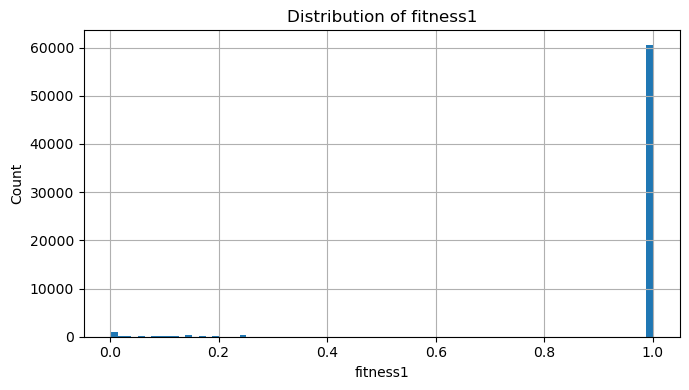

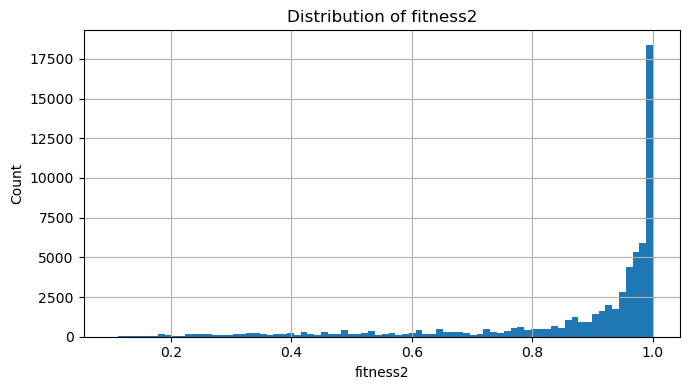

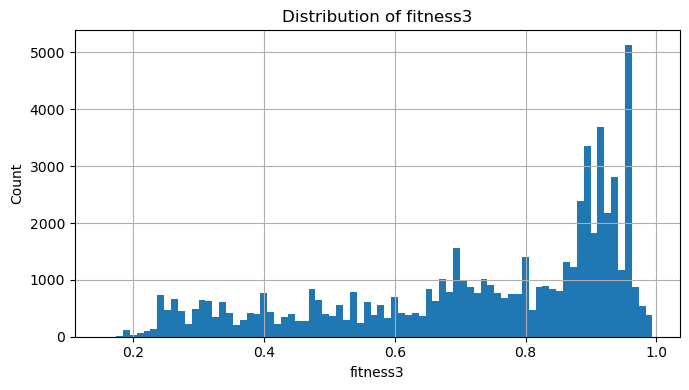

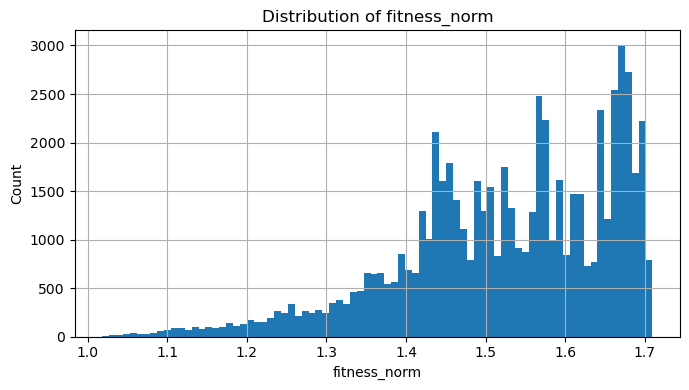

In [6]:
fitness_cols = [c for c in ["fitness1", "fitness2", "fitness3", "fitness_norm"] if c in df.columns]
display(df[fitness_cols].describe() if fitness_cols else "No fitness columns found.")

for col in fitness_cols:
    plt.figure(figsize=(7, 4))
    df[col].dropna().hist(bins=80)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


## 7. Fitness evolution by generation

This shows whether the top-k candidates improve across generations.


,mean,max,min,std,count
generation,,,,,
1,1.136620,1.574044,1.018304,0.093727,210
2,1.180929,1.574044,1.023600,0.102418,210
3,1.217555,1.574044,1.031996,0.101721,210
4,1.249553,1.574044,1.030382,0.102241,210
5,1.272590,1.574044,1.044976,0.112272,210


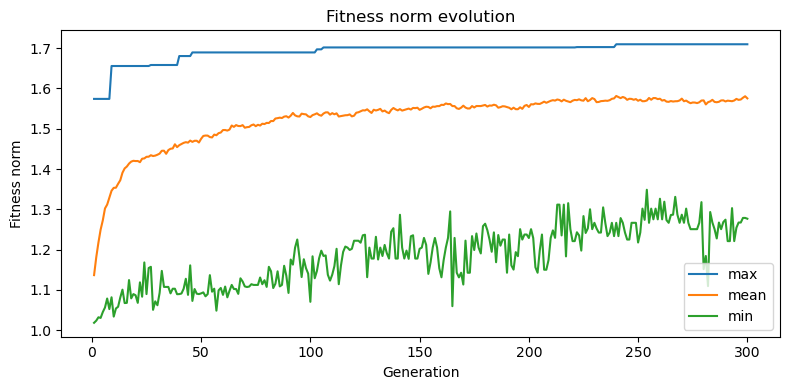

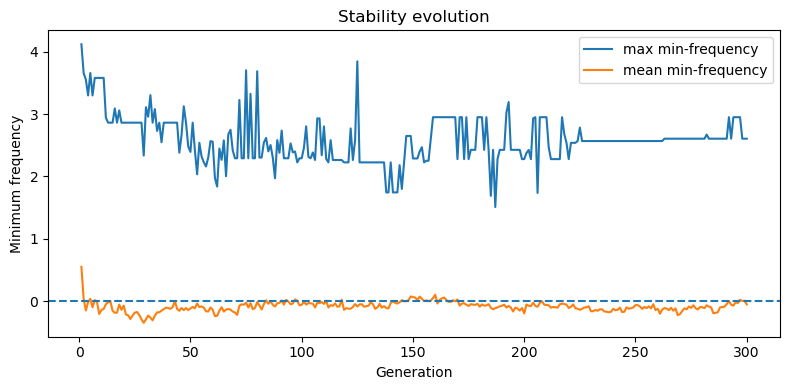

In [7]:
if "generation" in df.columns and "fitness_norm" in df.columns:
    gen_stats = df.groupby("generation")["fitness_norm"].agg(["mean", "max", "min", "std", "count"])
    display(gen_stats.head())

    plt.figure(figsize=(8, 4))
    gen_stats["max"].plot(label="max")
    gen_stats["mean"].plot(label="mean")
    gen_stats["min"].plot(label="min")
    plt.xlabel("Generation")
    plt.ylabel("Fitness norm")
    plt.title("Fitness norm evolution")
    plt.legend()
    plt.tight_layout()
    plt.show()

if "generation" in df.columns and "min_frequency" in df.columns:
    gen_minfreq = df.groupby("generation")["min_frequency"].agg(["mean", "max", "min"])
    plt.figure(figsize=(8, 4))
    gen_minfreq["max"].plot(label="max min-frequency")
    gen_minfreq["mean"].plot(label="mean min-frequency")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Generation")
    plt.ylabel("Minimum frequency")
    plt.title("Stability evolution")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 8. Parameter sweep maps

These plots summarize behavior over lattice parameter and mass, if `a_val` and `mass` or `atomic_masses` are available.


a_val,2.0,2.2,2.4,2.6,2.8,3.0,3.2
mass,,,,,,,
50.0,1.720015,1.693739,1.688118,1.671083,1.700897,1.719373,1.698311
60.0,1.661122,1.689866,1.720235,1.677457,1.716112,1.701034,1.714619
70.0,1.714717,1.716600,1.687752,1.688738,1.717333,1.695905,1.718512
80.0,1.713782,1.703258,1.712496,1.707105,1.718126,1.730783,1.698795
90.0,1.679061,1.727692,1.715597,1.709229,1.696160,1.684813,1.715645
100.0,1.726856,1.713956,1.725514,1.674312,1.705677,1.724566,1.703272


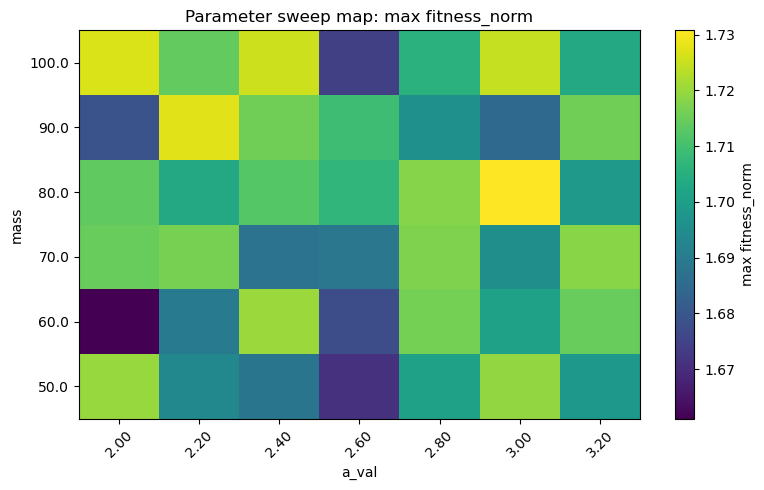

a_val,2.0,2.2,2.4,2.6,2.8,3.0,3.2
mass,,,,,,,
50.0,0.513333,0.673333,0.366000,0.626000,0.276000,0.540667,0.282667
60.0,0.604667,0.315333,0.363333,0.350000,0.367333,0.486000,0.628000
70.0,0.642667,0.617333,0.563333,0.647333,0.289333,0.663333,0.172667
80.0,0.464000,0.477333,0.248667,0.398000,0.620000,0.504667,0.284000
90.0,0.355333,0.736667,0.445333,0.492000,0.633333,0.671333,0.628667
100.0,0.662667,0.376000,0.350000,0.332000,0.592000,0.391333,0.403333


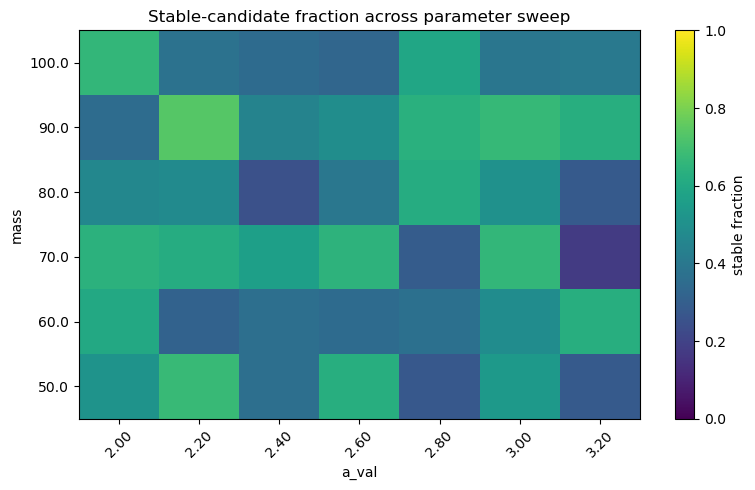

In [8]:
df_plot = df.copy()

if "mass" not in df_plot.columns and "atomic_masses" in df_plot.columns:
    def first_mass(x):
        if isinstance(x, (list, tuple, np.ndarray)):
            return float(x[0])
        return float(x)
    df_plot["mass"] = df_plot["atomic_masses"].map(first_mass)

metric = "fitness_norm" if "fitness_norm" in df_plot.columns else None
if metric and "a_val" in df_plot.columns and "mass" in df_plot.columns:
    pivot = df_plot.groupby(["mass", "a_val"])[metric].max().unstack("a_val")
    display(pivot)

    plt.figure(figsize=(8, 5))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.colorbar(label=f"max {metric}")
    plt.xticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns], rotation=45)
    plt.yticks(range(len(pivot.index)), [f"{x:.1f}" for x in pivot.index])
    plt.xlabel("a_val")
    plt.ylabel("mass")
    plt.title(f"Parameter sweep map: max {metric}")
    plt.tight_layout()
    plt.show()

if "is_stable" in df_plot.columns and "a_val" in df_plot.columns and "mass" in df_plot.columns:
    stable_fraction = df_plot.groupby(["mass", "a_val"])["is_stable"].mean().unstack("a_val")
    display(stable_fraction)

    plt.figure(figsize=(8, 5))
    plt.imshow(stable_fraction.values, aspect="auto", origin="lower", vmin=0, vmax=1)
    plt.colorbar(label="stable fraction")
    plt.xticks(range(len(stable_fraction.columns)), [f"{x:.2f}" for x in stable_fraction.columns], rotation=45)
    plt.yticks(range(len(stable_fraction.index)), [f"{x:.1f}" for x in stable_fraction.index])
    plt.xlabel("a_val")
    plt.ylabel("mass")
    plt.title("Stable-candidate fraction across parameter sweep")
    plt.tight_layout()
    plt.show()


## 9. Force-constant relationships

Scatter plots of the reduced BvK parameters and their relation to fitness/stability.


,alpha0,alpha1,beta1,alpha2,beta2
count,63000.000000,63000.000000,63000.000000,63000.000000,63000.000000
mean,7.307402,-0.435662,-0.010591,-0.421663,-0.739071
std,1.483153,0.228356,0.569242,0.644822,0.507338
min,1.083536,-1.690515,-1.997094,-1.999325,-1.997281
25%,6.284948,-0.585103,-0.446976,-0.833228,-1.060059
50%,7.242335,-0.444538,-0.013352,-0.172375,-0.760806
75%,8.517112,-0.284472,0.430042,0.000138,-0.435028
max,9.999665,0.397729,1.999406,1.998371,1.990763


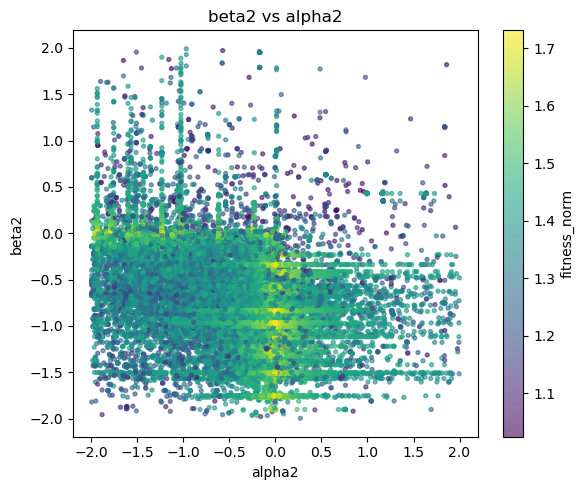

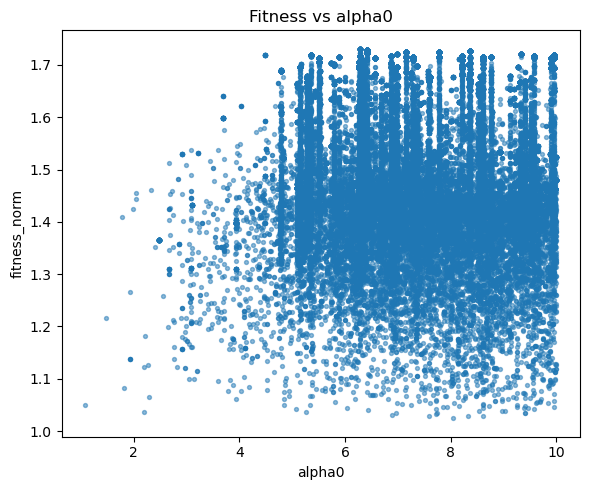

In [66]:
fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]
display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

if len(fc_cols) >= 2:
    color_col = "fitness_norm" if "fitness_norm" in df.columns else None
    xcol, ycol = "alpha2", "beta2"
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6, 5))
        if color_col:
            sc = plt.scatter(df[xcol], df[ycol], c=df[color_col], s=8, alpha=0.6)
            plt.colorbar(sc, label=color_col)
        else:
            plt.scatter(df[xcol], df[ycol], s=8, alpha=0.6)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.tight_layout()
        plt.show()

if "alpha0" in df.columns and "fitness_norm" in df.columns:
    plt.figure(figsize=(6, 5))
    plt.scatter(df["alpha0"], df["fitness_norm"], s=8, alpha=0.5)
    plt.xlabel("alpha0")
    plt.ylabel("fitness_norm")
    plt.title("Fitness vs alpha0")
    plt.tight_layout()
    plt.show()


,alpha0,alpha1,beta1,alpha2,beta2
count,63000.000000,63000.000000,63000.000000,63000.000000,63000.000000
mean,7.307402,-0.435662,-0.010591,-0.421663,-0.739071
std,1.483153,0.228356,0.569242,0.644822,0.507338
min,1.083536,-1.690515,-1.997094,-1.999325,-1.997281
25%,6.284948,-0.585103,-0.446976,-0.833228,-1.060059
50%,7.242335,-0.444538,-0.013352,-0.172375,-0.760806
75%,8.517112,-0.284472,0.430042,0.000138,-0.435028
max,9.999665,0.397729,1.999406,1.998371,1.990763


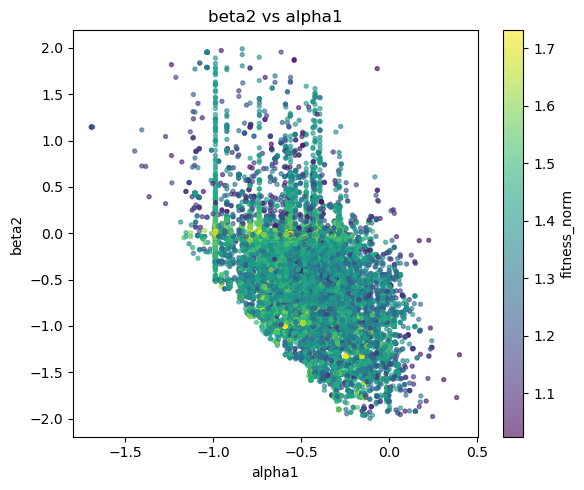

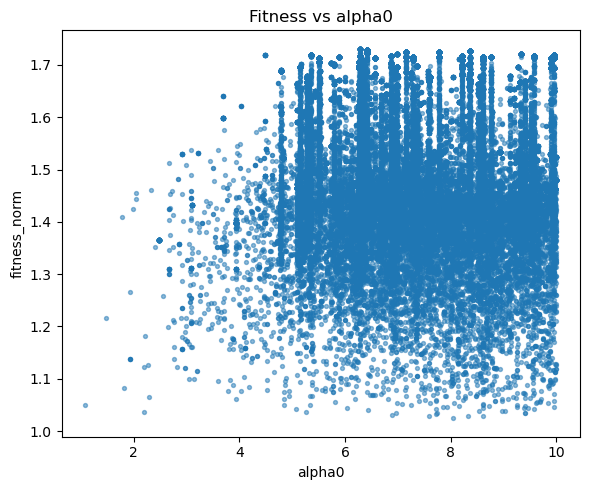

In [67]:
fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]
display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

if len(fc_cols) >= 2:
    color_col = "fitness_norm" if "fitness_norm" in df.columns else None
    xcol, ycol = "alpha1", "beta2"
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6, 5))
        if color_col:
            sc = plt.scatter(df[xcol], df[ycol], c=df[color_col], s=8, alpha=0.6)
            plt.colorbar(sc, label=color_col)
        else:
            plt.scatter(df[xcol], df[ycol], s=8, alpha=0.6)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.tight_layout()
        plt.show()

if "alpha0" in df.columns and "fitness_norm" in df.columns:
    plt.figure(figsize=(6, 5))
    plt.scatter(df["alpha0"], df["fitness_norm"], s=8, alpha=0.5)
    plt.xlabel("alpha0")
    plt.ylabel("fitness_norm")
    plt.title("Fitness vs alpha0")
    plt.tight_layout()
    plt.show()


,alpha0,alpha1,beta1,alpha2,beta2
count,63000.000000,63000.000000,63000.000000,63000.000000,63000.000000
mean,7.307402,-0.435662,-0.010591,-0.421663,-0.739071
std,1.483153,0.228356,0.569242,0.644822,0.507338
min,1.083536,-1.690515,-1.997094,-1.999325,-1.997281
25%,6.284948,-0.585103,-0.446976,-0.833228,-1.060059
50%,7.242335,-0.444538,-0.013352,-0.172375,-0.760806
75%,8.517112,-0.284472,0.430042,0.000138,-0.435028
max,9.999665,0.397729,1.999406,1.998371,1.990763


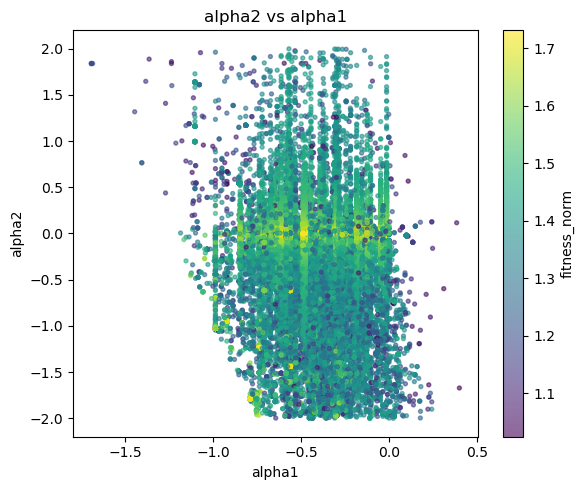

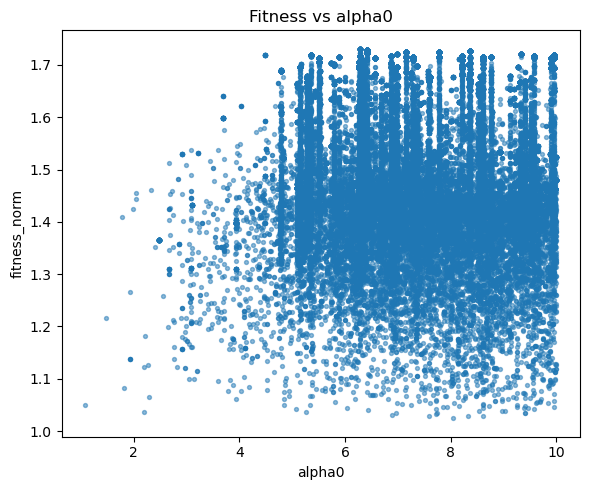

In [68]:
fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]
display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

if len(fc_cols) >= 2:
    color_col = "fitness_norm" if "fitness_norm" in df.columns else None
    xcol, ycol = "alpha1", "alpha2"
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6, 5))
        if color_col:
            sc = plt.scatter(df[xcol], df[ycol], c=df[color_col], s=8, alpha=0.6)
            plt.colorbar(sc, label=color_col)
        else:
            plt.scatter(df[xcol], df[ycol], s=8, alpha=0.6)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.tight_layout()
        plt.show()

if "alpha0" in df.columns and "fitness_norm" in df.columns:
    plt.figure(figsize=(6, 5))
    plt.scatter(df["alpha0"], df["fitness_norm"], s=8, alpha=0.5)
    plt.xlabel("alpha0")
    plt.ylabel("fitness_norm")
    plt.title("Fitness vs alpha0")
    plt.tight_layout()
    plt.show()

## 10. Top candidates

This table lists the highest-ranking candidates according to `fitness_norm`, with stable candidates prioritized if available.


In [10]:
preferred_cols = [
    "simulation_id", "generation", "solution_index", "rank",
    "a_val", "mass",
    "alpha0", "alpha1", "beta1", "alpha2", "beta2",
    "fitness1", "fitness2", "fitness3", "fitness_norm",
    "min_frequency", "num_imaginary", "is_stable",
    "yaml_path", "plot_path"
]
cols = [c for c in preferred_cols if c in df_plot.columns]

sort_cols = []
ascending = []
if "is_stable" in df_plot.columns:
    sort_cols.append("is_stable")
    ascending.append(False)
if "fitness_norm" in df_plot.columns:
    sort_cols.append("fitness_norm")
    ascending.append(False)
elif "min_frequency" in df_plot.columns:
    sort_cols.append("min_frequency")
    ascending.append(False)

top = df_plot.sort_values(sort_cols, ascending=ascending).head(25) if sort_cols else df_plot.head(25)
display(top[cols])


,generation,solution_index,rank,a_val,mass,alpha0,alpha1,beta1,alpha2,beta2,fitness1,fitness2,fitness3,fitness_norm,min_frequency,num_imaginary,is_stable
40310,263,46,0,3.0,80.0,6.285156,-0.578062,-0.473038,0.001104,-0.415166,1.0,0.997803,1.0,1.730783,0.081982,0,True
40315,264,1,0,3.0,80.0,6.285156,-0.578062,-0.473038,0.001104,-0.415166,1.0,0.997803,1.0,1.730783,0.081982,0,True
40320,265,1,0,3.0,80.0,6.285156,-0.578062,-0.473038,0.001104,-0.415166,1.0,0.997803,1.0,1.730783,0.081982,0,True
40325,266,1,0,3.0,80.0,6.285156,-0.578062,-0.473038,0.001104,-0.415166,1.0,0.997803,1.0,1.730783,0.081982,0,True
40330,267,1,0,3.0,80.0,6.285156,-0.578062,-0.473038,0.001104,-0.415166,1.0,0.997803,1.0,1.730783,0.081982,0,True
40335,268,1,0,3.0,80.0,6.285156,-0.578062,-0.473038,0.001104,-0.415166,1.0,0.997803,1.0,1.730783,0.081982,0,True
40340,269,1,0,3.0,80.0,6.285156,-0.578062,-0.473038,0.001104,-0.415166,1.0,0.997803,1.0,1.730783,0.081982,0,True
40345,270,1,0,3.0,80.0,6.285156,-0.578062,-0.473038,0.001104,-0.415166,1.0,0.997803,1.0,1.730783,0.081982,0,True
40350,271,1,0,3.0,80.0,6.285156,-0.578062,-0.473038,0.001104,-0.415166,1.0,0.997803,1.0,1.730783,0.081982,0,True
40355,272,1,0,3.0,80.0,6.285156,-0.578062,-0.473038,0.001104,-0.415166,1.0,0.997803,1.0,1.730783,0.081982,0,True


## 11. Save filtered subsets

Useful for making small curated datasets for plotting, manuscript figures, or Zenodo releases.


In [11]:
# Best row by fitness_norm for each (a_val, mass)
idx = df.groupby(["a_val", "mass"])["fitness_norm"].idxmax()

best_df = (
    df.loc[idx]
    .sort_values(["a_val", "mass"])
    .reset_index(drop=True)
)

best_df.head()

,simulation,generation,solution_index,rank,mass,a_val,alpha0,alpha1,beta1,alpha2,...,distances,qpoints,frequencies,simulation_path,phonon_root,generation_dir,band_yaml_path,source,sort_by,sort_score
0,simulation000420,275,9,0,50.0,2.0,6.977625,-0.471765,0.911910,-1.601738,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.14225446, 0.14225446, 0.14225446], [0.1500...",simulations/simulation000420,simulations/simulation000420/phonon_generations,simulations/simulation000420/phonon_generation...,simulations/simulation000420/phonon_generation...,population,fitness_norm,1.720015
1,simulation000427,292,46,0,60.0,2.0,6.771322,-0.157192,0.595287,-0.004124,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-0.11488084, -0.11488084, -0.11488084], [-0....",simulations/simulation000427,simulations/simulation000427/phonon_generations,simulations/simulation000427/phonon_generation...,simulations/simulation000427/phonon_generation...,population,fitness_norm,1.661122
2,simulation000434,195,19,0,70.0,2.0,8.617890,-0.654963,-1.047935,0.000693,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.07543893, 0.07543893, 0.07543893], [0.0891...",simulations/simulation000434,simulations/simulation000434/phonon_generations,simulations/simulation000434/phonon_generation...,simulations/simulation000434/phonon_generation...,population,fitness_norm,1.714717
3,simulation000441,274,85,0,80.0,2.0,5.511595,-0.048796,-0.388527,-0.000993,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-0.07121308, -0.07121308, -0.07121308], [-0....",simulations/simulation000441,simulations/simulation000441/phonon_generations,simulations/simulation000441/phonon_generation...,simulations/simulation000441/phonon_generation...,population,fitness_norm,1.713782
4,simulation000448,174,45,0,90.0,2.0,9.115006,-0.721636,0.708962,-0.007285,...,"[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-0.17740718, -0.17740718, -0.17740718], [-0....",simulations/simulation000448,simulations/simulation000448/phonon_generations,simulations/simulation000448/phonon_generation...,simulations/simulation000448/phonon_generation...,population,fitness_norm,1.679061


In [12]:
best_df[
    [
        "simulation",
        "generation",
        "a_val",
        "mass",
        "alpha0",
        "alpha1",
        "beta1",
        "alpha2",
        "beta2",
        "fitness_norm",
        "fitness1",
        "fitness2",
        "fitness3",
        "min_frequency",
        "num_imaginary",
    ]
]

,simulation,generation,a_val,mass,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm,fitness1,fitness2,fitness3,min_frequency,num_imaginary
0,simulation000420,275,2.0,50.0,6.977625,-0.471765,0.911910,-1.601738,0.001018,1.720015,1.0,0.995912,0.983163,-1.111129,79
1,simulation000427,292,2.0,60.0,6.771322,-0.157192,0.595287,-0.004124,-1.377200,1.661122,1.0,0.996747,0.875111,-0.114881,29
2,simulation000434,195,2.0,70.0,8.617890,-0.654963,-1.047935,0.000693,-0.844495,1.714717,1.0,0.998411,0.971304,0.075439,0
3,simulation000441,274,2.0,80.0,5.511595,-0.048796,-0.388527,-0.000993,-1.280216,1.713782,1.0,0.998381,0.969681,-0.071213,24
4,simulation000448,174,2.0,90.0,9.115006,-0.721636,0.708962,-0.007285,-0.834728,1.679061,1.0,0.988569,0.917594,-0.177407,40
5,simulation000455,246,2.0,100.0,8.372027,-0.737816,0.835176,-1.234718,0.000117,1.726856,1.0,0.999470,0.991510,0.035305,0
6,simulation000421,270,2.2,50.0,6.946175,-0.535399,0.541823,-0.004383,-0.665542,1.693739,1.0,0.992114,0.940459,-0.197004,39
7,simulation000428,277,2.2,60.0,4.789292,-0.106804,-0.034653,-0.000816,-0.983323,1.689866,1.0,0.999932,0.925085,-0.011054,9
8,simulation000435,149,2.2,70.0,9.566845,-0.444538,-0.771401,0.004702,-1.502609,1.716600,1.0,0.990579,0.982582,0.182027,0
9,simulation000442,275,2.2,80.0,6.284948,-0.393482,0.607003,0.007526,-0.784175,1.703258,1.0,0.984794,0.965023,0.217536,0


In [13]:
df_valid = df.dropna(subset=["fitness_norm"])

idx = df_valid.groupby(["a_val", "mass"])["fitness_norm"].idxmax()

best_df = (
    df_valid.loc[idx]
    .sort_values(["a_val", "mass"])
    .reset_index(drop=True)
)

In [14]:
from pathlib import Path

REPO_ROOT = Path.cwd()

best_df = best_df.copy()

best_df["dispersion_path"] = best_df["generation_dir"].apply(
    lambda p: REPO_ROOT / p / "dispersion.png"
)

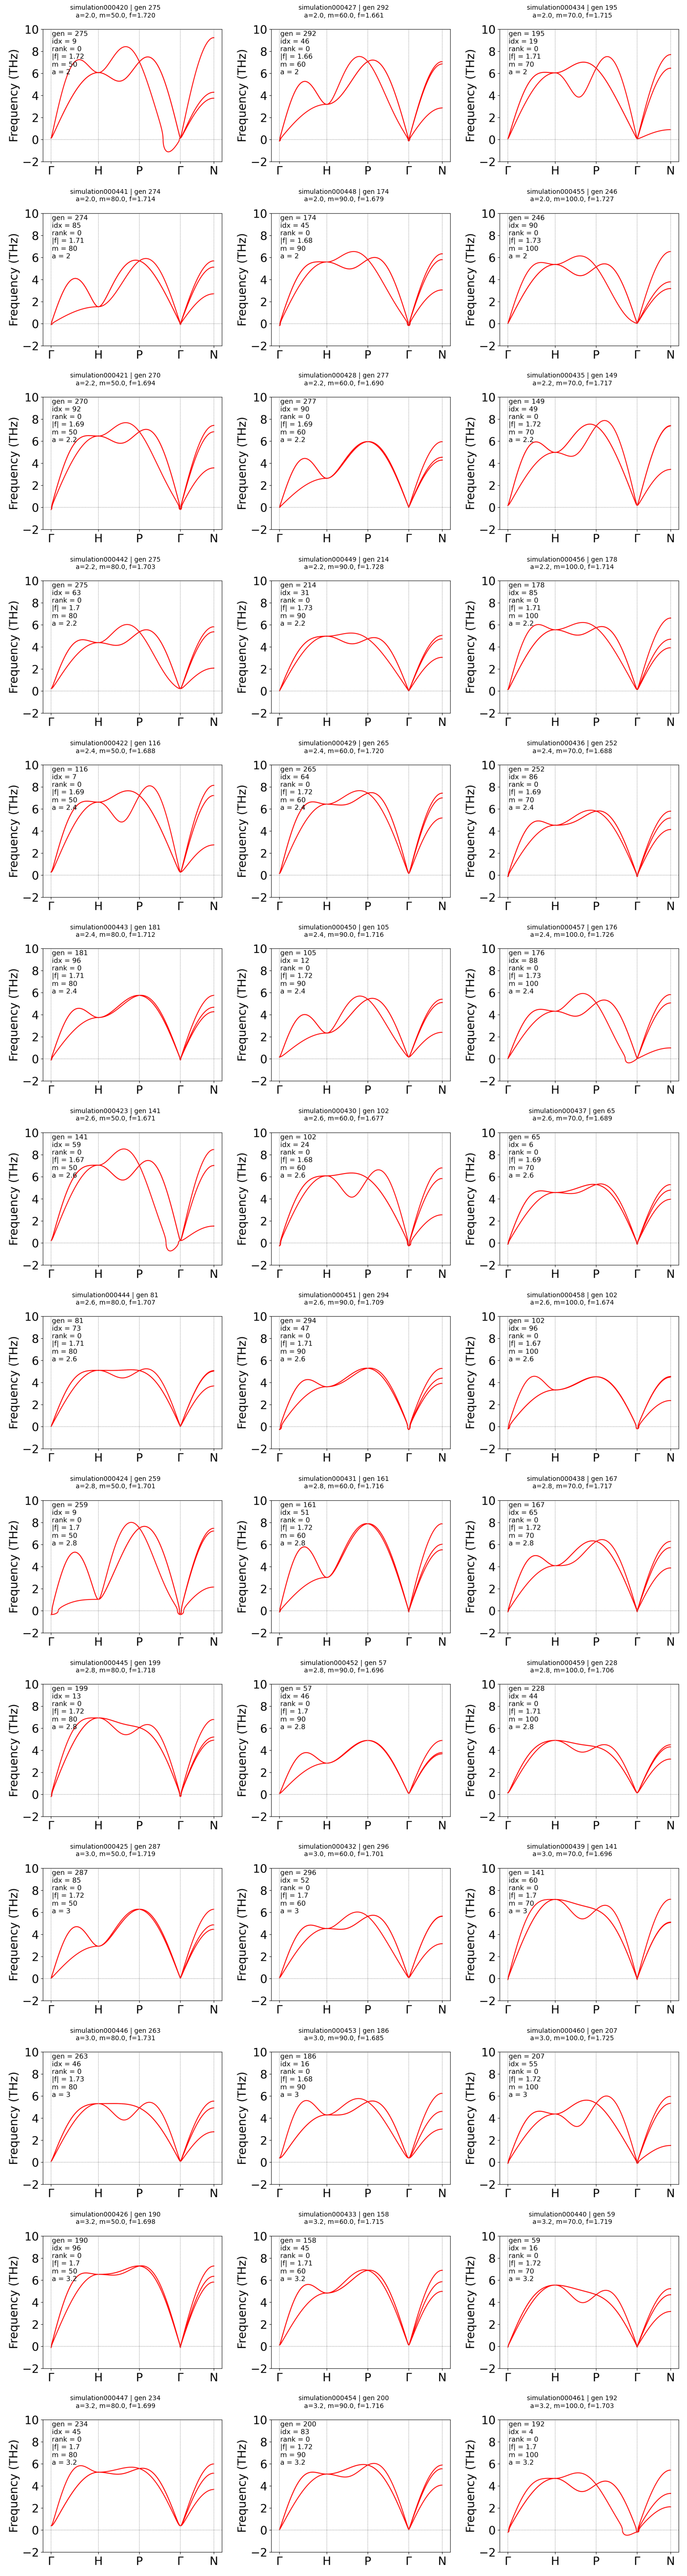

In [15]:
import math

n = len(best_df)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.ravel()

for ax, (_, row) in zip(axes, best_df.iterrows()):
    img = plt.imread(row["dispersion_path"])
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"{row['simulation']} | gen {row['generation']}\n"
        f"a={row['a_val']}, m={row['mass']}, "
        f"f={row['fitness_norm']:.3f}",
        fontsize=10,
    )

for ax in axes[len(best_df):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
output_dir = repo_root / "dataframes" / "subsets"
output_dir.mkdir(parents=True, exist_ok=True)

if "is_stable" in df_plot.columns:
    stable_df = df_plot[df_plot["is_stable"] == True].copy()
    stable_path = output_dir / f"{experiment_id}_stable_candidates.pkl"
    stable_df.to_pickle(stable_path)
    print("Saved stable candidates:", stable_path, "rows =", len(stable_df))

if "fitness_norm" in df_plot.columns:
    top_path = output_dir / f"{experiment_id}_top100_by_fitness_norm.pkl"
    df_plot.sort_values("fitness_norm", ascending=False).head(100).to_pickle(top_path)
    print("Saved top 100:", top_path)


Saved stable candidates: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/subsets/experiment000009_stable_candidates.pkl rows = 30083
Saved top 100: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/subsets/experiment000009_top100_by_fitness_norm.pkl


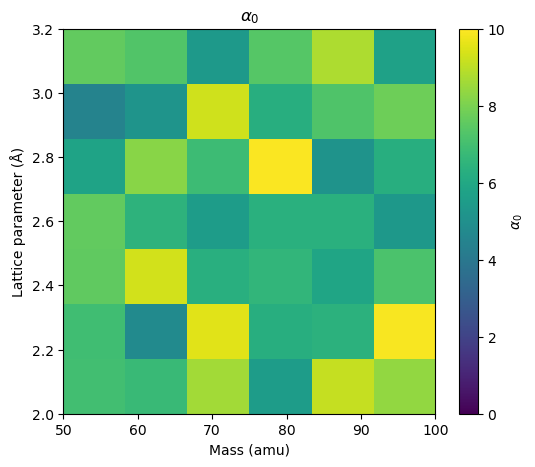

In [17]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="alpha0",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=0.0,
    vmax=10.0,
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_0$")

plt.colorbar(label=r"$\alpha_0$")

plt.show()

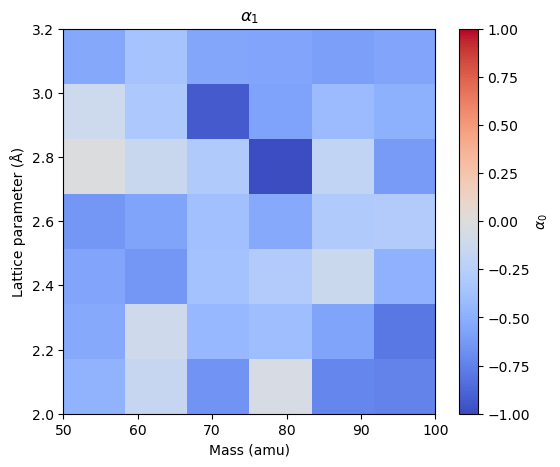

In [18]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="alpha1",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_1$")


plt.colorbar(label=r"$\alpha_0$")

plt.show()

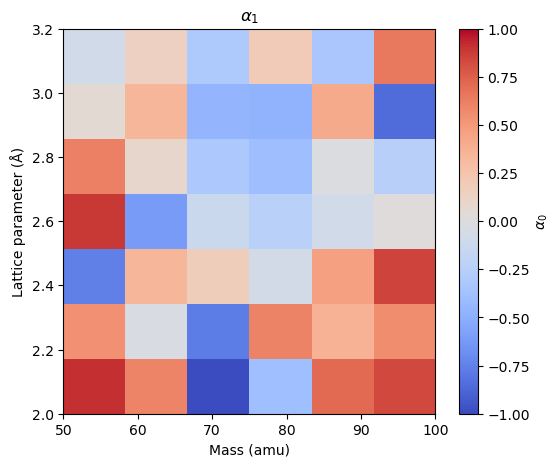

In [19]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="beta1",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_1$")


plt.colorbar(label=r"$\alpha_0$")

plt.show()

In [20]:
cols = [
    "mass",
    "a_val",
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
    "fitness_norm",
]

best_df[cols].corr()

,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm
mass,1.000000e+00,-9.826552e-16,0.083898,-0.218329,0.029314,-0.299994,0.328226,0.249177
a_val,-9.826552e-16,1.000000e+00,-0.147650,-0.048587,-0.230946,-0.017825,0.168777,0.090699
alpha0,8.389816e-02,-1.476503e-01,1.000000,-0.691161,-0.094030,-0.273735,0.073451,0.164171
alpha1,-2.183294e-01,-4.858684e-02,-0.691161,1.000000,0.097001,0.339159,-0.638382,-0.112907
beta1,2.931376e-02,-2.309459e-01,-0.094030,0.097001,1.000000,-0.270132,0.144372,-0.155146
alpha2,-2.999944e-01,-1.782461e-02,-0.273735,0.339159,-0.270132,1.000000,-0.731145,0.050889
beta2,3.282259e-01,1.687774e-01,0.073451,-0.638382,0.144372,-0.731145,1.000000,-0.047375
fitness_norm,2.491772e-01,9.069927e-02,0.164171,-0.112907,-0.155146,0.050889,-0.047375,1.000000


<Axes: >

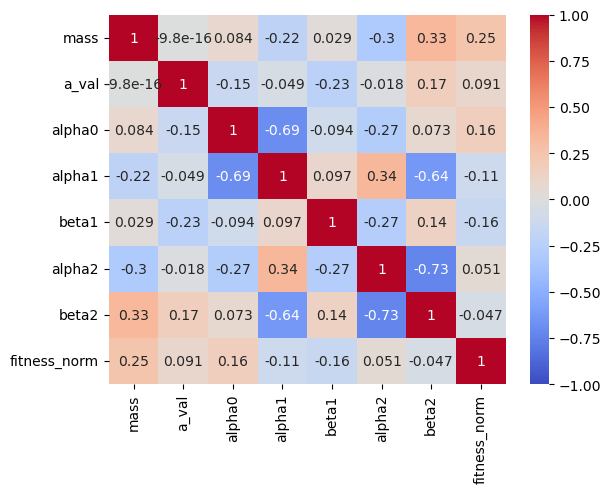

In [21]:
import seaborn as sns

sns.heatmap(best_df[cols].corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm")

In [22]:
X = best_df[
    ["alpha0","alpha1","beta1","alpha2","beta2"]
].values

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fc_cols = [
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
]

X = best_df[fc_cols].values

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [25]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [26]:
print(pca.explained_variance_ratio_)

[0.48217427 0.26863364]


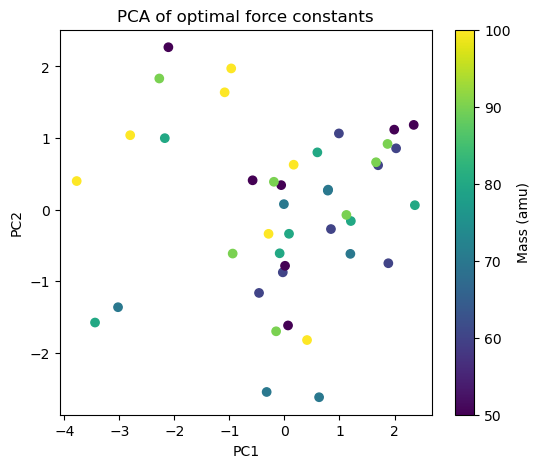

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=best_df["mass"],
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(sc, label="Mass (amu)")

plt.title("PCA of optimal force constants")

plt.show()

In [28]:
c=best_df["a_val"]

In [29]:
c=best_df["fitness_norm"]

In [30]:
loadings = pd.DataFrame(
    pca.components_,
    columns=fc_cols,
    index=["PC1", "PC2"],
)

loadings

,alpha0,alpha1,beta1,alpha2,beta2
PC1,-0.388106,0.548077,-0.087643,0.502382,-0.537509
PC2,-0.517164,0.341473,0.638692,-0.357130,0.283670


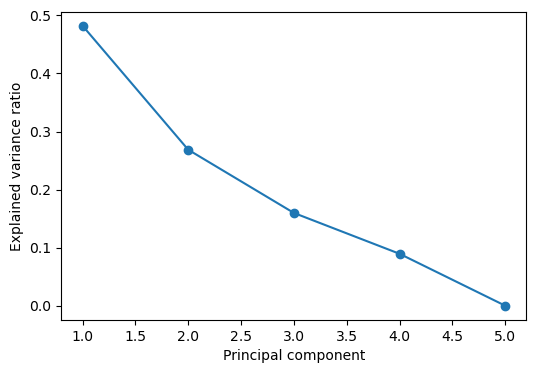

In [31]:
pca_full = PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(fc_cols)+1),
    pca_full.explained_variance_ratio_,
    marker="o",
)

plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")

plt.show()

In [32]:
pca_full = PCA()

pca_full.fit(X_scaled)

print(pca_full.explained_variance_ratio_)

[4.82174273e-01 2.68633645e-01 1.59770004e-01 8.94187770e-02
 3.30162173e-06]


In [33]:
loadings_full = pd.DataFrame(
    pca_full.components_,
    columns=fc_cols,
    index=[f"PC{i+1}" for i in range(len(fc_cols))]
)

loadings_full

,alpha0,alpha1,beta1,alpha2,beta2
PC1,-0.388106,0.548077,-0.087643,0.502382,-0.537509
PC2,-0.517164,0.341473,0.638692,-0.357130,0.283670
PC3,0.549157,-0.016457,0.699854,0.084311,-0.448610
PC4,-0.286513,-0.515828,0.307564,0.692708,0.278195
PC5,0.445255,0.562724,0.000189,0.364853,0.593272


In [34]:
best_df["PC5"] = pca_full.transform(X_scaled)[:,4]

In [35]:
best_df["PC5"].describe()

count    4.200000e+01
mean    -2.725994e-18
std      4.112268e-03
min     -8.942541e-03
25%     -2.277668e-03
50%      1.265688e-04
75%      1.328387e-03
max      1.152830e-02
Name: PC5, dtype: float64

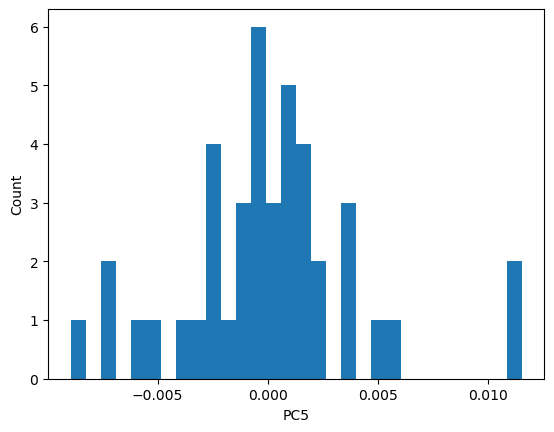

In [36]:
plt.hist(best_df["PC5"], bins=30)
plt.xlabel("PC5")
plt.ylabel("Count")
plt.show()

In [37]:
best_df.loc[best_df["PC5"].abs().idxmax()]

simulation                                                     simulation000453
generation                                                                  186
solution_index                                                               16
rank                                                                          0
mass                                                                       90.0
a_val                                                                       3.0
alpha0                                                                 7.242335
alpha1                                                                -0.421286
beta1                                                                  0.409912
alpha2                                                                -1.935806
beta2                                                                  0.013322
fitness                           [1.0, 0.9490185599580281, 0.9684823741328716]
fitness1                                

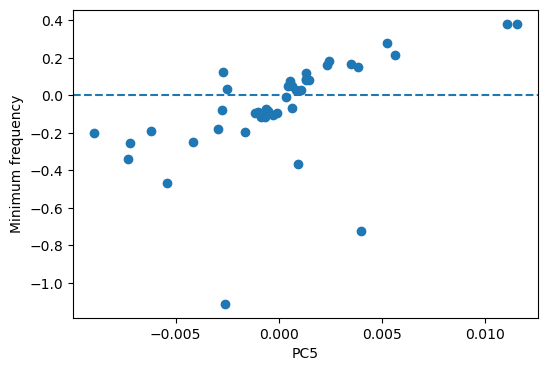

In [38]:
plt.figure(figsize=(6,4))

sc = plt.scatter(
    best_df["PC5"],
    best_df["min_frequency"],
)

plt.xlabel("PC5")
plt.ylabel("Minimum frequency")

plt.axhline(0, linestyle="--")

plt.show()

In [39]:
from scipy.stats import linregress

res = linregress(
    best_df["PC5"],
    best_df["min_frequency"],
)

print(res)

LinregressResult(slope=np.float64(36.89691670092859), intercept=np.float64(-0.062378360956374994), rvalue=np.float64(0.5593178377169826), pvalue=np.float64(0.00011785092162048802), stderr=np.float64(8.646323278995538), intercept_stderr=np.float64(0.03513016007210929))


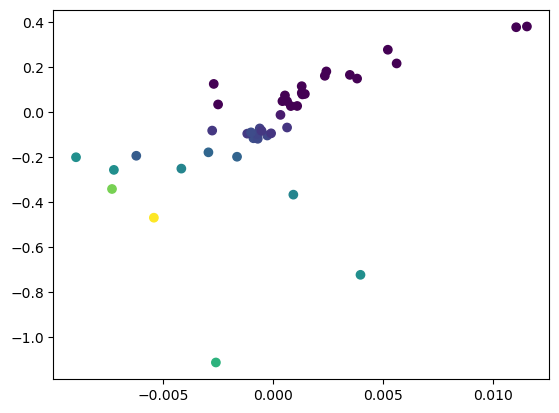

In [40]:
plt.scatter(
    best_df["PC5"],
    best_df["min_frequency"],
    c=best_df["num_imaginary"],
)

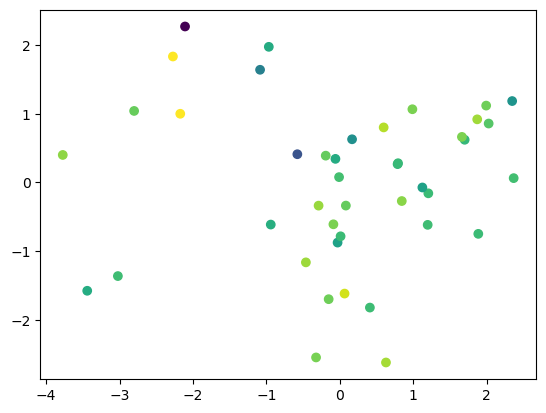

In [41]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=best_df["min_frequency"],
)

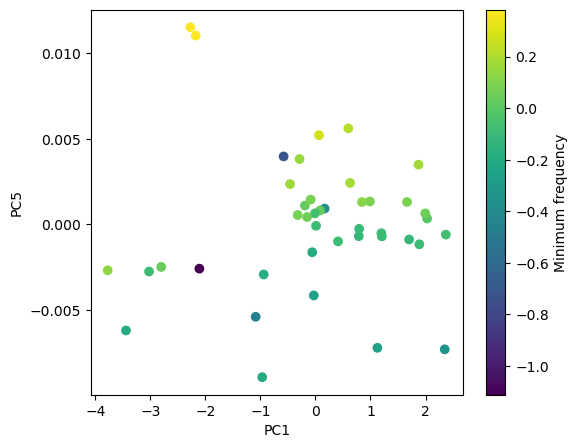

In [42]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,0],
    best_df["PC5"],
    c=best_df["min_frequency"],
)

plt.xlabel("PC1")
plt.ylabel("PC5")

plt.colorbar(sc, label="Minimum frequency")

plt.show()

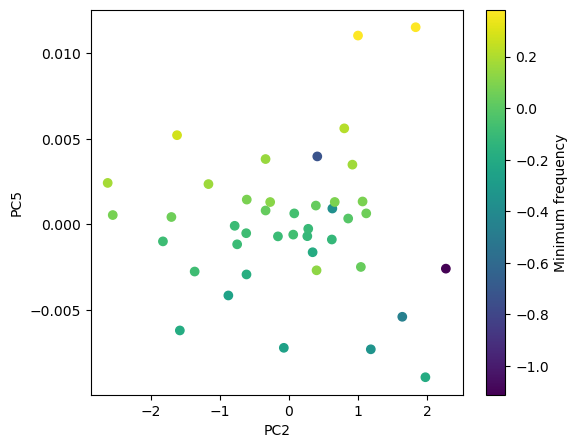

In [43]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,1],
    best_df["PC5"],
    c=best_df["min_frequency"],
)

plt.xlabel("PC2")
plt.ylabel("PC5")

plt.colorbar(sc, label="Minimum frequency")

plt.show()

In [44]:
best_df["frequency_vector"] = best_df["frequencies"].apply(
    lambda x: x.reshape(-1)
)

In [45]:
X_freq = np.stack(best_df["frequency_vector"].values)

In [46]:
X_freq.shape

(42, 2412)

In [47]:
import umap

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)

X_umap = reducer.fit_transform(X_freq)

/Users/jamunoz/miniconda3/envs/moga/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


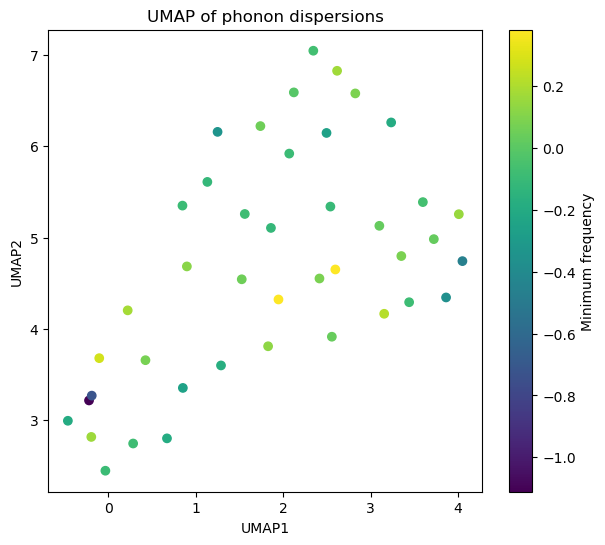

In [48]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=best_df["min_frequency"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="Minimum frequency")

plt.title("UMAP of phonon dispersions")

plt.show()

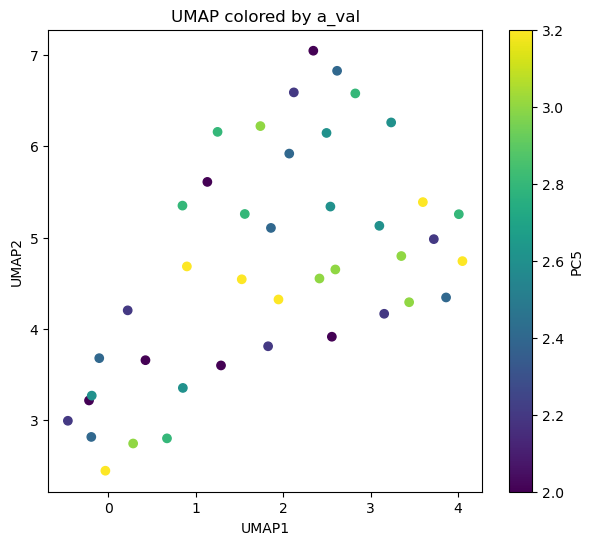

In [56]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=best_df["a_val"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="PC5")

plt.title("UMAP colored by a_val")

plt.show()

In [57]:
fc_cols = [
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
]

X_fc = best_df[fc_cols].values

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_fc_scaled = scaler.fit_transform(X_fc)

In [59]:
import umap

reducer_fc = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)

X_fc_umap = reducer_fc.fit_transform(X_fc_scaled)

/Users/jamunoz/miniconda3/envs/moga/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


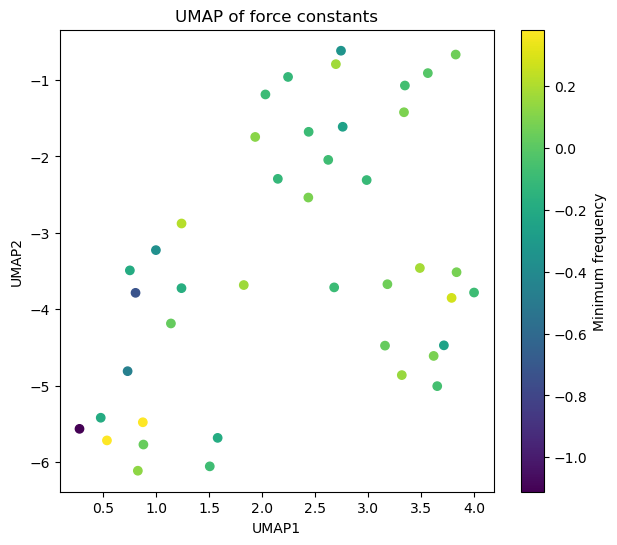

In [65]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["min_frequency"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="Minimum frequency")

plt.title("UMAP of force constants")

plt.show()

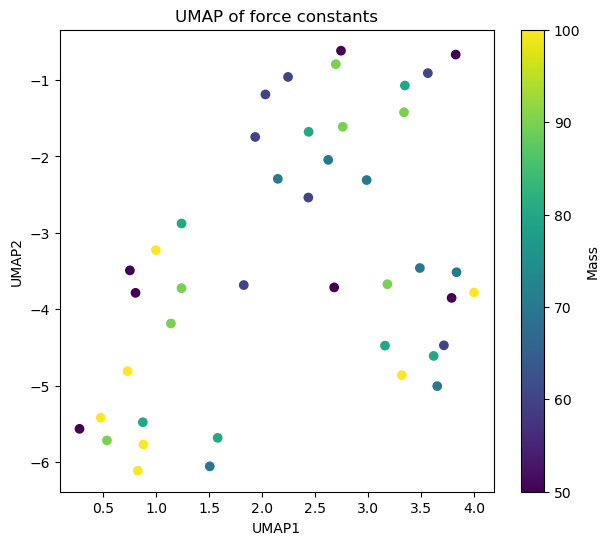

In [61]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["mass"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="Mass")

plt.title("UMAP of force constants")

plt.show()

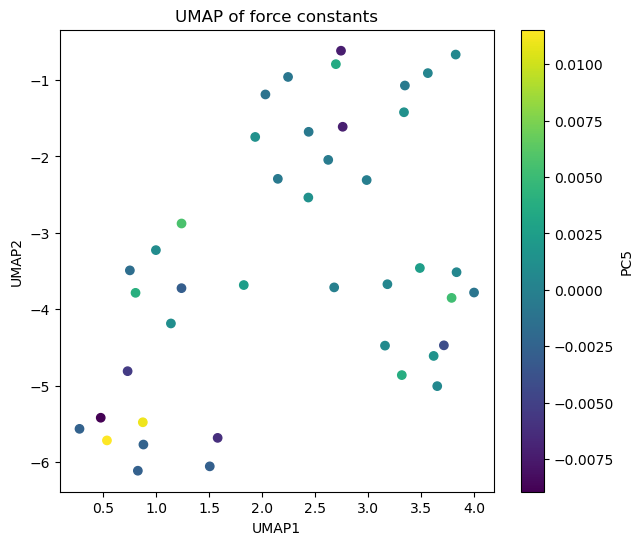

In [63]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["PC5"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="PC5")

plt.title("UMAP of force constants")

plt.show()

In [ ]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["a_val"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="a_val")

plt.title("UMAP of force constants")

plt.show()

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr, spearmanr

In [70]:
fc_cols = ["alpha0", "alpha1", "beta1", "alpha2", "beta2"]

X_fc = best_df[fc_cols].to_numpy(dtype=np.float32)

X_ph = np.stack(
    best_df["frequencies"].apply(lambda x: x.reshape(-1)).values
).astype(np.float32)

In [71]:
X_fc_scaled = StandardScaler().fit_transform(X_fc)
X_ph_scaled = StandardScaler().fit_transform(X_ph)

In [72]:
D_fc = pairwise_distances(X_fc_scaled, metric="euclidean")
D_ph = pairwise_distances(X_ph_scaled, metric="euclidean")

In [73]:
iu = np.triu_indices_from(D_fc, k=1)

d_fc = D_fc[iu]
d_ph = D_ph[iu]

r_pearson = pearsonr(d_fc, d_ph)
r_spearman = spearmanr(d_fc, d_ph)

print("Pearson r:", r_pearson.statistic, "p =", r_pearson.pvalue)
print("Spearman rho:", r_spearman.statistic, "p =", r_spearman.pvalue)

Pearson r: 0.3563016 p = 3.595245052509888e-27
Spearman rho: 0.3646199800675733 p = 1.8205161729791141e-28


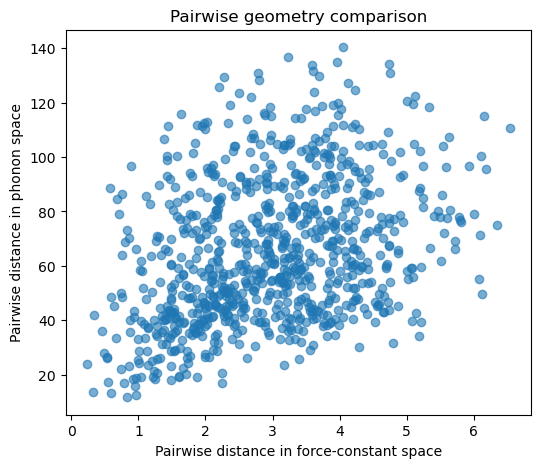

In [74]:
plt.figure(figsize=(6,5))

plt.scatter(d_fc, d_ph, alpha=0.6)

plt.xlabel("Pairwise distance in force-constant space")
plt.ylabel("Pairwise distance in phonon space")
plt.title("Pairwise geometry comparison")

plt.show()

In [75]:
def knn_indices(D, k):
    return np.argsort(D, axis=1)[:, 1:k+1]


def neighborhood_overlap(D1, D2, k):
    nn1 = knn_indices(D1, k)
    nn2 = knn_indices(D2, k)

    overlaps = []

    for a, b in zip(nn1, nn2):
        overlaps.append(
            len(set(a).intersection(set(b))) / k
        )

    return np.array(overlaps)

In [76]:
ks = [1, 2, 3, 5, 8, 10, 15, 20]

overlaps = []

for k in ks:
    ov = neighborhood_overlap(D_fc, D_ph, k)
    overlaps.append(ov.mean())

overlaps = np.array(overlaps)

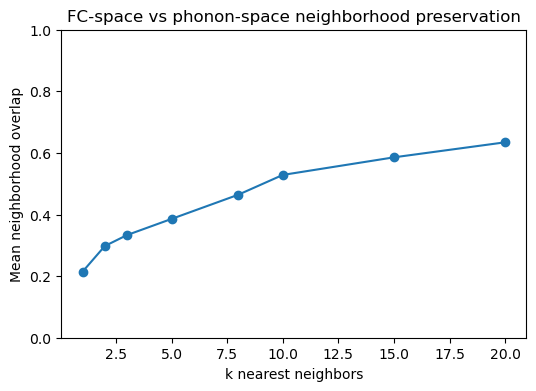

In [77]:
plt.figure(figsize=(6,4))

plt.plot(ks, overlaps, marker="o")

plt.xlabel("k nearest neighbors")
plt.ylabel("Mean neighborhood overlap")
plt.title("FC-space vs phonon-space neighborhood preservation")

plt.ylim(0, 1)

plt.show()

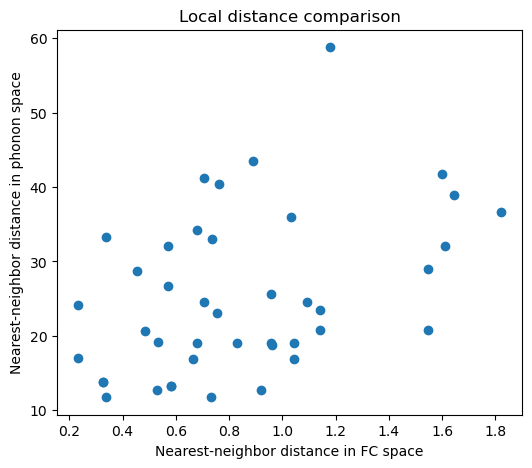

In [78]:
nearest_fc = np.min(D_fc + np.eye(len(D_fc))*1e9, axis=1)
nearest_ph = np.min(D_ph + np.eye(len(D_ph))*1e9, axis=1)

plt.figure(figsize=(6,5))

plt.scatter(nearest_fc, nearest_ph)

plt.xlabel("Nearest-neighbor distance in FC space")
plt.ylabel("Nearest-neighbor distance in phonon space")
plt.title("Local distance comparison")

plt.show()

In [79]:
pairs = pd.DataFrame({
    "i": iu[0],
    "j": iu[1],
    "d_fc": d_fc,
    "d_ph": d_ph,
})

pairs["folding_score"] = pairs["d_fc"] / (pairs["d_ph"] + 1e-8)

folded_pairs = pairs.sort_values("folding_score", ascending=False)

folded_pairs.head(10)

,i,j,d_fc,d_ph,folding_score
415,11,31,5.188960,34.095291,0.152190
398,11,14,4.791452,31.843204,0.150470
424,11,40,4.284214,30.281458,0.141480
814,31,40,3.174158,23.678511,0.134052
508,14,40,2.250718,16.872486,0.133396
184,4,31,3.395595,25.666809,0.132295
410,11,26,5.208613,39.477970,0.131937
404,11,20,5.073565,39.620491,0.128054
414,11,30,6.119870,49.582932,0.123427
858,39,40,3.564018,29.278946,0.121726


In [80]:
i, j = folded_pairs.iloc[0][["i", "j"]].astype(int)

best_df.iloc[[i, j]][
    [
        "simulation",
        "generation",
        "mass",
        "a_val",
        "alpha0",
        "alpha1",
        "beta1",
        "alpha2",
        "beta2",
        "fitness_norm",
        "min_frequency",
        "num_imaginary",
    ]
]

,simulation,generation,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm,min_frequency,num_imaginary
11,simulation000456,178,100.0,2.2,9.897008,-0.789914,0.555748,-1.788726,0.001567,1.713956,0.126524,0
31,simulation000432,296,60.0,3.0,5.166245,-0.315896,0.338786,0.000402,-0.659567,1.701034,0.079970,0


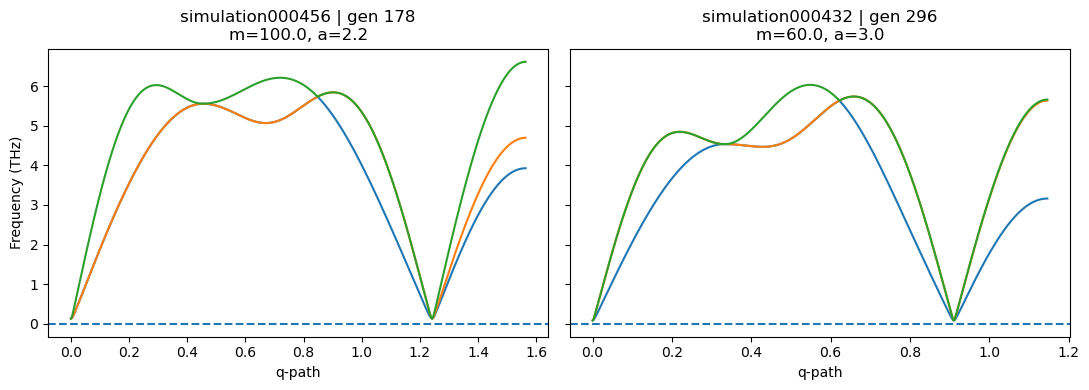

In [81]:
def plot_two_dispersions(row1, row2):
    fig, axes = plt.subplots(1, 2, figsize=(11,4), sharey=True)

    for ax, row in zip(axes, [row1, row2]):
        distances = row["distances"]
        freqs = row["frequencies"]

        for b in range(freqs.shape[1]):
            ax.plot(distances, freqs[:, b])

        ax.axhline(0, linestyle="--")
        ax.set_title(
            f"{row['simulation']} | gen {row['generation']}\n"
            f"m={row['mass']}, a={row['a_val']}"
        )
        ax.set_xlabel("q-path")

    axes[0].set_ylabel("Frequency (THz)")

    plt.tight_layout()
    plt.show()


plot_two_dispersions(best_df.iloc[i], best_df.iloc[j])

,alpha0,alpha1,beta1,alpha2,beta2
count,63000.000000,63000.000000,63000.000000,63000.000000,63000.000000
mean,7.224368,-0.499852,-0.021127,-0.483727,-0.538633
std,1.953578,0.312008,0.525427,0.678333,0.594970
min,1.014421,-1.549441,-1.986075,-1.999179,-1.996837
25%,5.847196,-0.751951,-0.388633,-1.017480,-1.033658
50%,7.570248,-0.484973,0.006113,-0.220486,-0.339674
75%,8.850801,-0.236605,0.312109,-0.004008,-0.021427
max,9.999475,0.702125,1.996081,1.999712,1.912431


/var/folders/q4/9jxwyrx94pq6gsv5757mtyf80000gr/T/ipykernel_33978/1057657544.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


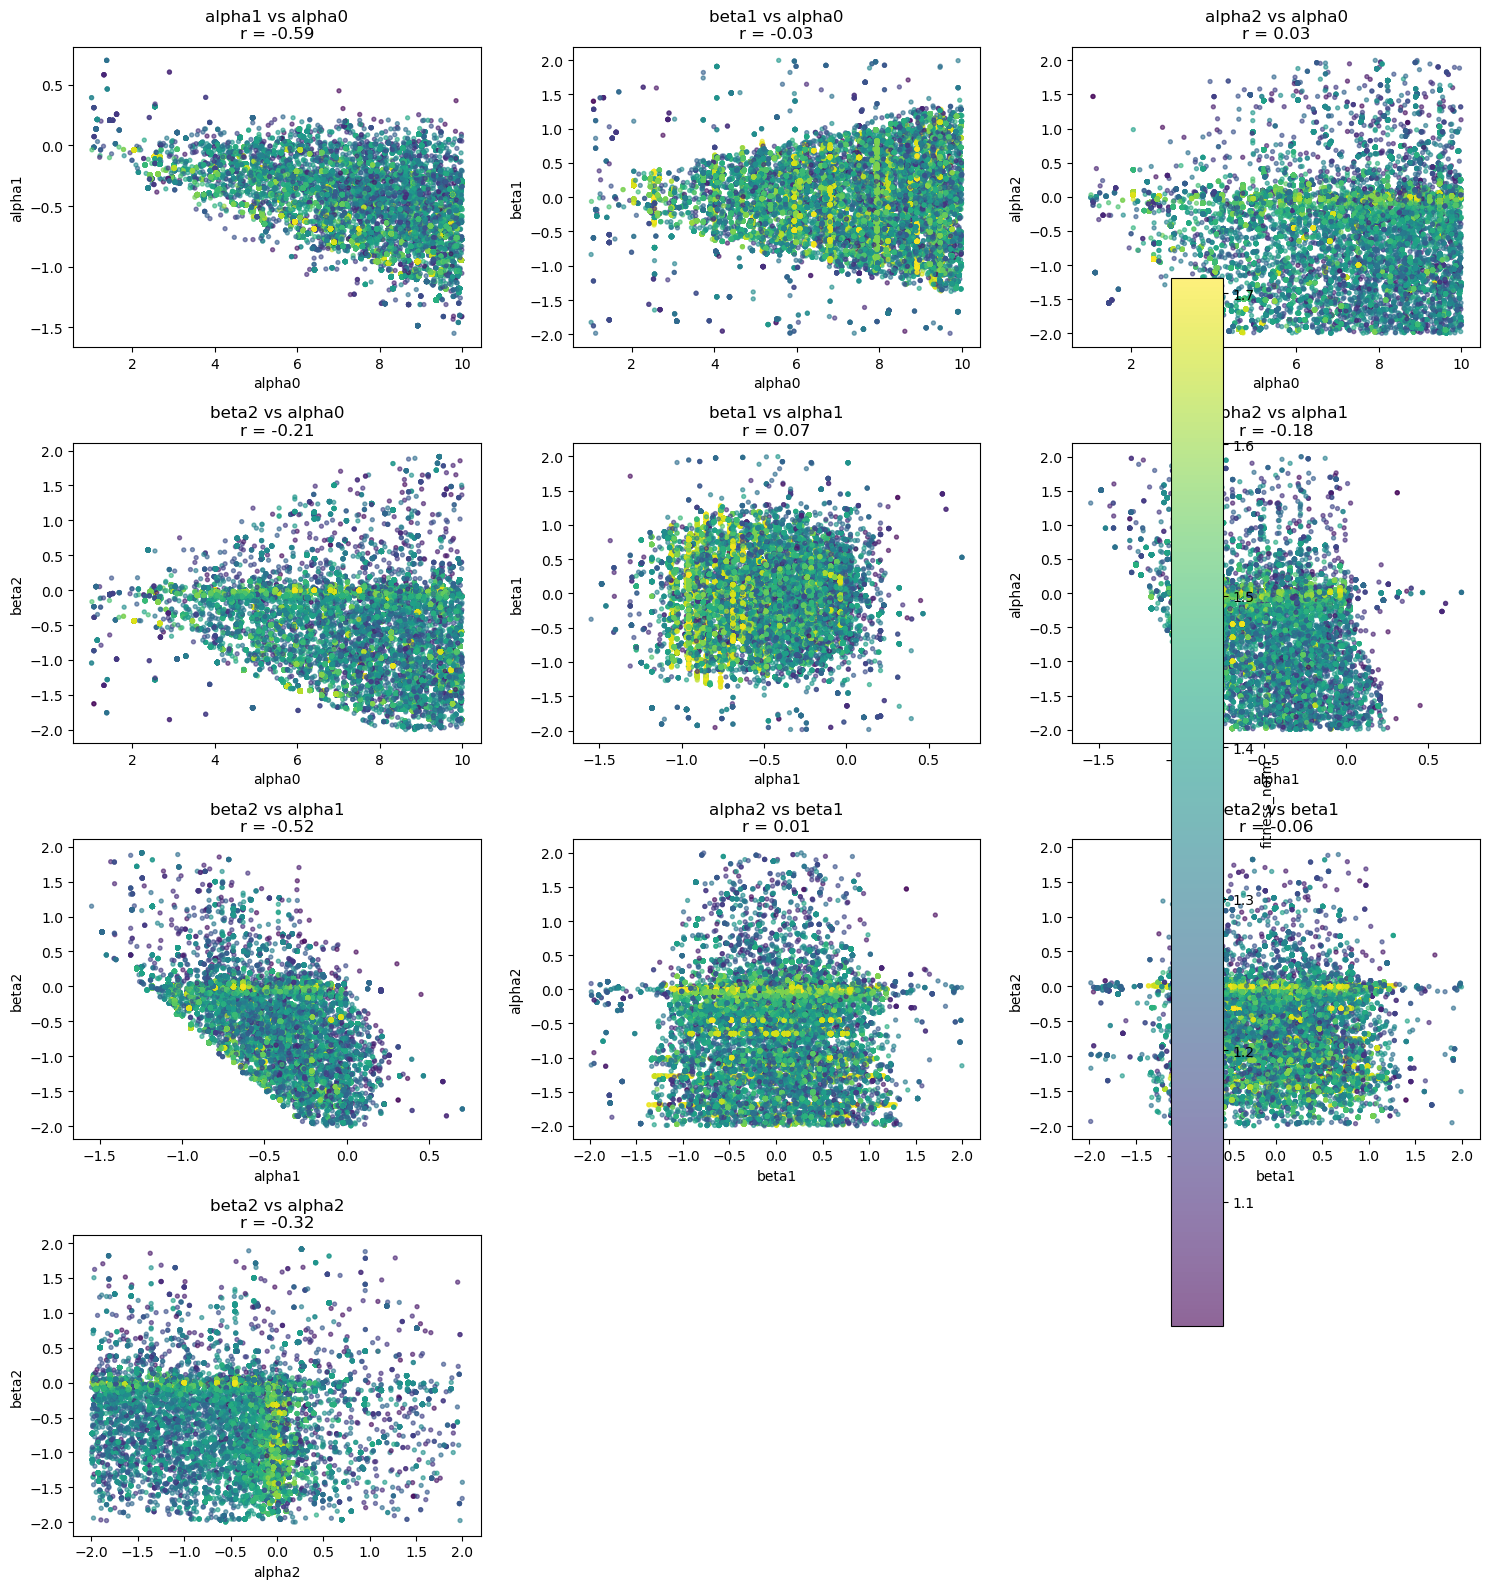

In [8]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]

display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

color_col = "fitness_norm" if "fitness_norm" in df.columns else None

pairs = list(itertools.combinations(fc_cols, 2))

ncols = 3
nrows = int(np.ceil(len(pairs) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5*ncols, 4*nrows),
)

axes = np.ravel(axes)

for ax, (xcol, ycol) in zip(axes, pairs):

    if color_col:
        sc = ax.scatter(
            df[xcol],
            df[ycol],
            c=df[color_col],
            s=8,
            alpha=0.6,
        )
    else:
        ax.scatter(
            df[xcol],
            df[ycol],
            s=8,
            alpha=0.6,
        )

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    r = df[[xcol, ycol]].corr().iloc[0, 1]
    ax.set_title(f"{ycol} vs {xcol}\nr = {r:.2f}")

for ax in axes[len(pairs):]:
    ax.axis("off")

if color_col:
    cbar = fig.colorbar(sc, ax=axes.tolist(), shrink=0.85)
    cbar.set_label(color_col)

plt.tight_layout()
plt.show()